# Notebook 08 — Model D: BiLSTM + Label Attention (LAAT)

**Architecture**: Implements the Label Attention Model from [Vu et al., IJCAI 2020](https://www.ijcai.org/proceedings/2020/461).

**Key differences from Model C (BERT-based)**:
- **Encoder**: BiLSTM (trained from scratch) instead of pre-trained ClinicalBERT
- **Input**: Full document as word tokens (up to 4,000 words) — no chunking needed
- **Embeddings**: Word-level (learned) instead of subword BPE
- **Label Attention**: Same concept — per-label query vectors attend over encoder hidden states

**Pipeline**: Word tokens → Embedding → BiLSTM → Label Attention → Per-label FFN → Sigmoid

## 1. Config & GPU Check

In [1]:
import sys
sys.path.insert(0, '..')

import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path

from src.config import (
    DATA_DIR, MODEL_D_DIR, SEED,
    MODEL_D_EMBED_DIM, MODEL_D_HIDDEN_DIM, MODEL_D_NUM_LAYERS,
    MODEL_D_ATTN_DIM, MODEL_D_DROPOUT, MODEL_D_LR, MODEL_D_EPOCHS,
    MODEL_D_BATCH_SIZE, MODEL_D_GRAD_ACCUM, MODEL_D_MAX_TOKENS,
    MODEL_D_VOCAB_SIZE, MODEL_D_EARLY_STOP,
    MODEL_D_FOCAL_GAMMA, MODEL_D_FOCAL_ALPHA,
    USE_AMP,
)
from src.train import set_seed

SAVE_DIR = MODEL_D_DIR
SAVE_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    print('No GPU detected — BiLSTM is lighter than BERT but GPU still recommended')

print(f'\nModel D Config:')
print(f'  Embedding dim:   {MODEL_D_EMBED_DIM}')
print(f'  BiLSTM hidden:   {MODEL_D_HIDDEN_DIM} (x2 bidirectional = {MODEL_D_HIDDEN_DIM * 2})')
print(f'  Attention dim:   {MODEL_D_ATTN_DIM}')
print(f'  Max tokens:      {MODEL_D_MAX_TOKENS}')
print(f'  Vocab size:      {MODEL_D_VOCAB_SIZE}')
print(f'  Batch size:      {MODEL_D_BATCH_SIZE}')
print(f'  Epochs:          {MODEL_D_EPOCHS} (early stop patience={MODEL_D_EARLY_STOP})')
print(f'  Learning rate:   {MODEL_D_LR}')
print(f'  Dropout:         {MODEL_D_DROPOUT}')
print(f'  Device:          {device}')

GPU: NVIDIA L4 (23.7 GB)

Model D Config:
  Embedding dim:   200
  BiLSTM hidden:   256 (x2 bidirectional = 512)
  Attention dim:   256
  Max tokens:      4000
  Vocab size:      50000
  Batch size:      32
  Epochs:          10 (early stop patience=3)
  Learning rate:   0.001
  Dropout:         0.3
  Device:          cuda


## 2. Load Data & Labels

In [2]:
from src.data import load_splits, load_label_binarizer, build_label_matrix

train_df, val_df, test_df = load_splits()
mlb = load_label_binarizer()
vocab = list(mlb.classes_)
NUM_LABELS = len(vocab)

Y_train = build_label_matrix(train_df, mlb)
Y_val   = build_label_matrix(val_df, mlb)
Y_test  = build_label_matrix(test_df, mlb)

print(f'Labels: {NUM_LABELS}')
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print(f'Y_train shape: {Y_train.shape}')
print(f'Label density: {Y_train.mean():.4f}')

/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00160J2', '00160J6', '00163J4', '00163J6', '00164J6', '00520ZZ', '005C0ZZ', '005T0ZZ', '008Q0ZZ', '008Q4ZZ', '008X0ZZ', '009000Z', '00900ZZ', '009030Z', '00903ZZ', '00904ZZ', '00920ZZ', '009300Z', '00930ZX', '00930ZZ', '009330Z', '00933ZZ', '009400Z', '00940ZZ', '009430Z', '00943ZZ', '00944ZZ', '00950ZZ', '00953ZX', '009600Z', '00960ZZ', '009630Z', '00963ZX', '00963ZZ', '009640Z', '009700Z', '00970ZZ', '00973ZX', '00973ZZ', '009C0ZZ', '009T00Z', '009T0ZZ', '009T30Z', '009T3ZX', '009U00Z', '009U0ZX', '009U0ZZ', '009U30Z', '009U3ZX', '009U3ZZ', '009W00Z', '009W0ZZ', '009X3ZX', '009X3ZZ', '009Y30Z', '009Y3ZX', '009Y3ZZ', '00B00ZX', '00B00ZZ', '00B03ZX', '00B03ZZ', '00B04ZZ', '00B10ZX', '00B10ZZ', '00B13ZX', '00B14ZZ', '00B20ZX', '00B20ZZ', '00B23ZX', '00B24ZZ', '00B60ZX', '00B60ZZ', '00B70ZX', '00B70ZZ', '00B73ZX', '00B80ZX', '00B83ZX', '00B90ZX', '00B90ZZ', '00B93ZX', '00

Labels: 50
Train: 85081  Val: 18371  Test: 18852
Y_train shape: (85081, 50)
Label density: 0.1016


/home/croha/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['00160J6', '00163J6', '00164J6', '00560ZZ', '008Q4ZZ', '009000Z', '00900ZZ', '00903ZZ', '00910ZX', '00910ZZ', '009300Z', '009400Z', '00940ZZ', '009430Z', '00943ZZ', '00944ZZ', '009600Z', '009630Z', '00963ZX', '009640Z', '00970ZZ', '009C3ZX', '009T30Z', '009U00Z', '009U0ZZ', '009U30Z', '009U3ZX', '009U3ZZ', '009Y30Z', '009Y3ZX', '009Y4ZZ', '00B00ZX', '00B00ZZ', '00B03ZX', '00B04ZX', '00B10ZZ', '00B13ZZ', '00B20ZX', '00B20ZZ', '00B23ZX', '00B60ZX', '00B60ZZ', '00B70ZX', '00B70ZZ', '00B73ZX', '00B83ZX', '00B90ZX', '00B93ZX', '00BC0ZX', '00BC0ZZ', '00BM0ZZ', '00BQ0ZZ', '00BT0ZX', '00BT0ZZ', '00BW0ZX', '00BW0ZZ', '00BX0ZX', '00BX0ZZ', '00BY0ZX', '00BY0ZZ', '00C00ZZ', '00C03ZZ', '00C10ZZ', '00C30ZZ', '00C40ZZ', '00C43ZZ', '00C70ZZ', '00CC0ZZ', '00CT0ZZ', '00CU0ZZ', '00CW0ZZ', '00CX0ZZ', '00CY0ZZ', '00D20ZZ', '00H00MZ', '00H032Z', '00H03MZ', '00HU03Z', '00HU0MZ', '00HU33Z', '00

## 3. Build Word Vocabulary

Unlike Models B/C which use BERT's subword tokenizer, the BiLSTM model uses word-level tokenization. We build a vocabulary from the training set (top 50K most frequent words).

In [3]:
from src.data import build_word_vocab

# Build vocabulary from training texts only (no data leakage)
word2idx = build_word_vocab(train_df['clean_text'], max_vocab_size=MODEL_D_VOCAB_SIZE)

# Save for reuse (inference, API, etc.)
with open(DATA_DIR / 'word_vocab.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
print(f'Saved word_vocab.pkl ({len(word2idx):,} words)')

# Quick stats
train_lengths = train_df['clean_text'].apply(lambda t: len(t.split()))
print(f'\nDocument length stats (words):')
print(f'  Mean:   {train_lengths.mean():.0f}')
print(f'  Median: {train_lengths.median():.0f}')
print(f'  95th:   {train_lengths.quantile(0.95):.0f}')
print(f'  Max:    {train_lengths.max()}')
print(f'  > {MODEL_D_MAX_TOKENS} tokens: {(train_lengths > MODEL_D_MAX_TOKENS).mean():.1%} of docs (will be truncated)')

Built word vocab: 50,000 words (from 605,293 unique tokens)
Saved word_vocab.pkl (50,000 words)

Document length stats (words):
  Mean:   1681
  Median: 1574
  95th:   2920
  Max:    7440
  > 4000 tokens: 0.8% of docs (will be truncated)


## 4. Create Datasets & DataLoaders

In [4]:
from src.data import BiLSTMDataset
from torch.utils.data import DataLoader

train_ds = BiLSTMDataset(train_df['clean_text'], Y_train, word2idx, max_tokens=MODEL_D_MAX_TOKENS)
val_ds   = BiLSTMDataset(val_df['clean_text'],   Y_val,   word2idx, max_tokens=MODEL_D_MAX_TOKENS)
test_ds  = BiLSTMDataset(test_df['clean_text'],  Y_test,  word2idx, max_tokens=MODEL_D_MAX_TOKENS)

train_loader = DataLoader(train_ds, batch_size=MODEL_D_BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=MODEL_D_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=MODEL_D_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

# Verify a single sample
sample = train_ds[0]
print(f'\nSample shapes:')
print(f'  input_ids:      {sample["input_ids"].shape}')       # (max_tokens,)
print(f'  attention_mask: {sample["attention_mask"].shape}')   # (max_tokens,)
print(f'  labels:         {sample["labels"].shape}')           # (num_labels,)
print(f'  real tokens:    {sample["attention_mask"].sum().item()}')

Train batches: 2659  Val: 575  Test: 590

Sample shapes:
  input_ids:      torch.Size([4000])
  attention_mask: torch.Size([4000])
  labels:         torch.Size([50])
  real tokens:    1371


## 5. Build BiLSTM-LAAT Model

In [5]:
from src.models import BiLSTMLAAT

model = BiLSTMLAAT(
    vocab_size=len(word2idx),
    num_labels=NUM_LABELS,
    embed_dim=MODEL_D_EMBED_DIM,
    hidden_dim=MODEL_D_HIDDEN_DIM,
    num_layers=MODEL_D_NUM_LAYERS,
    attn_dim=MODEL_D_ATTN_DIM,
    dropout=MODEL_D_DROPOUT,
).to(device)

total_params   = sum(p.numel() for p in model.parameters())
trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters:     {total_params:>12,}')
print(f'Trainable parameters: {trainable:>12,}')
print(f'\nFor comparison:')
print(f'  Model B (ClinicalBERT):        108,348,722')
print(f'  Model C (Chunk+LabelAttn):     108,387,122')
print(f'  Model D (BiLSTM-LAAT):         {trainable:>12,}  ← much lighter!')

# Smoke test: forward pass
with torch.no_grad():
    test_batch = next(iter(train_loader))
    test_ids = test_batch['input_ids'][:2].to(device)
    test_mask = test_batch['attention_mask'][:2].to(device)
    test_out = model(test_ids, test_mask)
    print(f'\nSmoke test: input {test_ids.shape} → output {test_out.shape}  ✓')

Total parameters:       11,107,506
Trainable parameters:   11,107,506

For comparison:
  Model B (ClinicalBERT):        108,348,722
  Model C (Chunk+LabelAttn):     108,387,122
  Model D (BiLSTM-LAAT):           11,107,506  ← much lighter!

Smoke test: input torch.Size([2, 4000]) → output torch.Size([2, 50])  ✓


## 6. Training

Single-phase training (no frozen backbone — BiLSTM is trained from scratch). Uses focal loss for class imbalance handling and early stopping to prevent overfitting.

In [6]:
from src.train import train_model

print('='*60)
print('Training BiLSTM-LAAT with Focal Loss + Early Stopping')
print('='*60)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_dir=SAVE_DIR,
    lr=MODEL_D_LR,
    epochs=MODEL_D_EPOCHS,
    grad_accum=MODEL_D_GRAD_ACCUM,
    warmup_ratio=0.05,
    use_focal_loss=True,
    focal_gamma=MODEL_D_FOCAL_GAMMA,
    focal_alpha=MODEL_D_FOCAL_ALPHA,
    checkpoint_every=5000,
    is_chunked=False,           # BiLSTM is NOT chunked
    early_stopping_patience=MODEL_D_EARLY_STOP,
    device=device,
)

Training BiLSTM-LAAT with Focal Loss + Early Stopping
  Using Focal Loss (gamma=2.0, alpha=0.25)
  Step 500/2659  loss=0.0468  GPU mem: 0.2GB
  Step 1000/2659  loss=0.0368  GPU mem: 0.2GB
  Step 1500/2659  loss=0.0321  GPU mem: 0.2GB
  Step 2000/2659  loss=0.0289  GPU mem: 0.2GB
  Step 2500/2659  loss=0.0268  GPU mem: 0.2GB
Epoch 1/10  loss=0.0263  val_F1@0.5=0.5605  val_F1@0.350=0.6651
  -> saved best checkpoint (tuned F1=0.6651 @ t=0.350)
  Step 500/2659  loss=0.0173  GPU mem: 0.2GB
  Step 1000/2659  loss=0.0173  GPU mem: 0.2GB
  Step 1500/2659  loss=0.0171  GPU mem: 0.2GB
  Step 2000/2659  loss=0.0170  GPU mem: 0.2GB
  Step 2500/2659  loss=0.0170  GPU mem: 0.2GB
Epoch 2/10  loss=0.0169  val_F1@0.5=0.5885  val_F1@0.350=0.6944
  -> saved best checkpoint (tuned F1=0.6944 @ t=0.350)
  Step 500/2659  loss=0.0162  GPU mem: 0.2GB
  Step 1000/2659  loss=0.0161  GPU mem: 0.2GB
  Step 1500/2659  loss=0.0161  GPU mem: 0.2GB
  Step 2000/2659  loss=0.0160  GPU mem: 0.2GB
  Step 2500/2659  loss=0

## 7. Training History

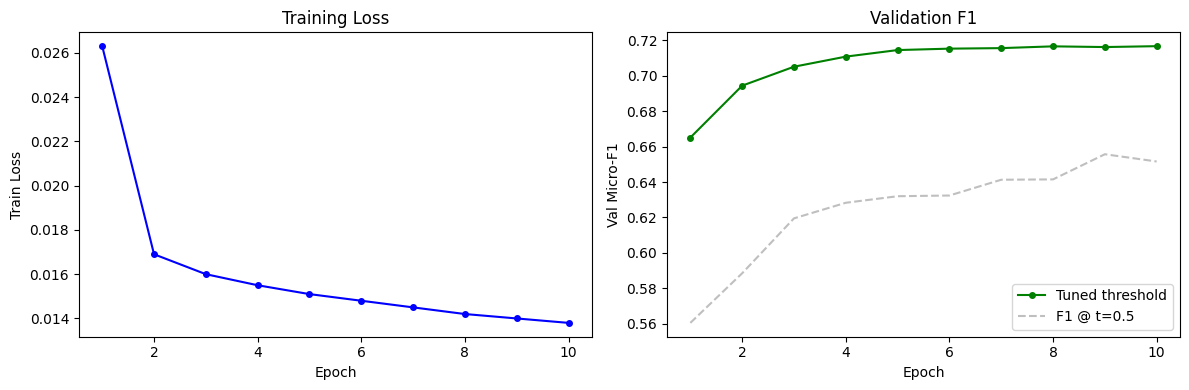

 epoch  train_loss  val_f1_at_0.5  val_f1_tuned  best_threshold
     1      0.0263         0.5605        0.6651           0.350
     2      0.0169         0.5885        0.6944           0.350
     3      0.0160         0.6195        0.7051           0.375
     4      0.0155         0.6283        0.7108           0.375
     5      0.0151         0.6320        0.7145           0.375
     6      0.0148         0.6324        0.7153           0.350
     7      0.0145         0.6413        0.7156           0.375
     8      0.0142         0.6415        0.7166           0.375
     9      0.0140         0.6557        0.7162           0.375
    10      0.0138         0.6516        0.7167           0.375


In [7]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(hist_df['epoch'], hist_df['train_loss'], 'b-o', markersize=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss'); ax1.set_title('Training Loss')

# Val F1 (tuned vs default)
ax2.plot(hist_df['epoch'], hist_df['val_f1_tuned'], 'g-o', markersize=4, label='Tuned threshold')
ax2.plot(hist_df['epoch'], hist_df['val_f1_at_0.5'], 'gray', linestyle='--', alpha=0.5, label='F1 @ t=0.5')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Micro-F1'); ax2.set_title('Validation F1')
ax2.legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150)
plt.show()
print(hist_df.to_string(index=False))

## 8. Temperature Scaling (Calibration)

In [8]:
from src.models import TemperatureScaler
from src.train import collect_logits
from src.evaluate import tune_global_threshold, expected_calibration_error
import torch as th

# Reload best model
model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pt', map_location=device))
model.eval()

# Collect raw logits on validation set
print('Collecting validation logits...')
val_logits, val_labels = collect_logits(
    model, val_loader, device=device, use_amp=USE_AMP, is_chunked=False,
)

# Fit temperature scaler
scaler = TemperatureScaler()
T = scaler.fit(val_logits, val_labels)

# Compare calibration before and after
probs_uncal = th.sigmoid(th.tensor(val_logits)).numpy()
probs_cal   = scaler.calibrate(val_logits)

ece_before = expected_calibration_error(probs_uncal, val_labels)
ece_after  = expected_calibration_error(probs_cal, val_labels)

t_before, f1_before = tune_global_threshold(probs_uncal, val_labels)
t_after, f1_after   = tune_global_threshold(probs_cal, val_labels)

print(f'\nCalibration Results:')
print(f'  Before: ECE={ece_before:.4f}  best_t={t_before:.3f}  F1={f1_before:.4f}')
print(f'  After:  ECE={ece_after:.4f}  best_t={t_after:.3f}  F1={f1_after:.4f}')
print(f'  Temperature: {T:.4f}')

# Save temperature
import json
with open(SAVE_DIR / 'temperature.json', 'w') as f:
    json.dump({'temperature': T, 'ece_before': ece_before, 'ece_after': ece_after}, f, indent=2)

Optimal temperature: 0.6308

Calibration Results:
  Before: ECE=0.0713  best_t=0.375  F1=0.7167
  After:  ECE=0.0218  best_t=0.300  F1=0.7170
  Temperature: 0.6308


## 9. Test Evaluation

In [9]:
from src.evaluate import full_metrics, tune_per_label_threshold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# Collect test logits
print('Computing test predictions...')
test_logits, Y_test_np = collect_logits(
    model, test_loader, device=device, use_amp=USE_AMP, is_chunked=False,
)

# Calibrated probabilities
P_test_cal = scaler.calibrate(test_logits)
# Uncalibrated probabilities
P_test_uncal = th.sigmoid(th.tensor(test_logits)).numpy()

# Global threshold (on calibrated probs, tuned on val)
best_t_global, _ = tune_global_threshold(probs_cal, val_labels)
results_global = full_metrics(P_test_cal, Y_test_np, best_t_global, 'Model D (BiLSTM-LAAT)')

print('\n=== Test Results (Global Threshold) ===')
for k, v in results_global.items():
    print(f'  {k:15s}: {v}')

# Save results
with open(SAVE_DIR / 'test_results.json', 'w') as f:
    json.dump(results_global, f, indent=2)
np.save(SAVE_DIR / 'P_test_calibrated.npy', P_test_cal)
np.save(SAVE_DIR / 'P_test_uncalibrated.npy', P_test_uncal)
np.save(SAVE_DIR / 'P_val_best.npy', probs_cal)
np.save(SAVE_DIR / 'Y_val_best.npy', val_labels)
print('\nResults saved to', SAVE_DIR)

Computing test predictions...

=== Test Results (Global Threshold) ===
  Model          : Model D (BiLSTM-LAAT)
  Threshold      : 0.3
  Micro-F1       : 0.7176
  Macro-F1       : 0.6635
  Micro-Prec     : 0.7171
  Micro-Rec      : 0.7181
  Macro-AUPRC    : 0.6805
  Micro-AUROC    : 0.9523

Results saved to /home/croha/ICD-CPT-Code-Prediction/data/models/model_d


## 10. Head / Torso / Tail Analysis

Bucket                          n   Avg F1
---------------------------------------------
head (>=500)                   50   0.6635


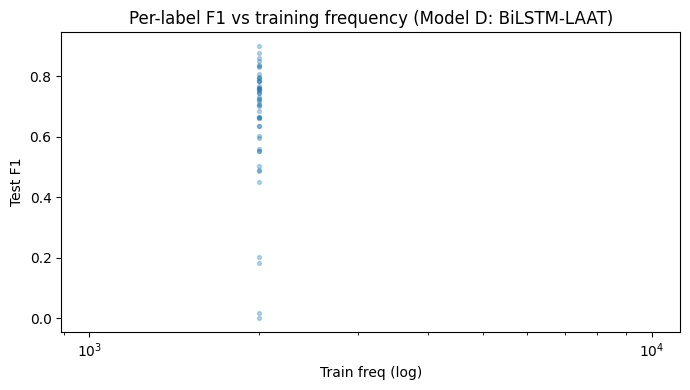

In [10]:
preds_test = (P_test_cal >= best_t_global).astype(int)
per_label_f1 = f1_score(Y_test_np, preds_test, average=None, zero_division=0)
per_label_freq = Y_train.sum(0)

label_df = pd.DataFrame({
    'icd_code': vocab, 'train_freq': per_label_freq, 'test_f1': per_label_f1,
})

print(f'{"Bucket":25s}  {"n":>6}  {"Avg F1":>7}')
print('-' * 45)
for lo, hi, name in [(500, 1e9, 'head (>=500)'), (100, 499, 'torso (100-499)'), (0, 99, 'tail (<100)')]:
    s = label_df[(label_df['train_freq'] >= lo) & (label_df['train_freq'] <= hi)]
    if len(s) == 0:
        continue
    print(f'{name:25s}  {len(s):6d}  {s["test_f1"].mean():7.4f}')

plt.figure(figsize=(7, 4))
plt.scatter(label_df['train_freq'].clip(upper=2000), label_df['test_f1'], alpha=0.3, s=8)
plt.xscale('log'); plt.xlabel('Train freq (log)'); plt.ylabel('Test F1')
plt.title('Per-label F1 vs training frequency (Model D: BiLSTM-LAAT)')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'head_tail_f1.png', dpi=120)
plt.show()

## 11. Compare All Models

Side-by-side comparison: Model A (TF-IDF), Model B (ClinicalBERT), Model C (Chunk+BERT+LabelAttn), Model D (BiLSTM+LabelAttn).

In [11]:
from src.config import MODEL_A_DIR, MODEL_B_DIR, MODEL_C_DIR

# Load other models' results
with open(MODEL_A_DIR / 'results.json') as f:
    res_a = json.load(f)
with open(MODEL_B_DIR / 'test_results.json') as f:
    res_b = json.load(f)

# Model C v1
res_c1 = None
try:
    with open(MODEL_C_DIR / 'test_results.json') as f:
        res_c1 = json.load(f)
except FileNotFoundError:
    pass

# Model C v2
res_c2 = None
try:
    with open(MODEL_C_DIR / 'v2' / 'test_results.json') as f:
        c2_data = json.load(f)
        res_c2 = c2_data.get('global_threshold', c2_data)
except FileNotFoundError:
    pass

rows = [
    {'Model': 'A: TF-IDF + SGD',
     'Micro-F1': res_a['test']['micro_f1'],
     'Macro-F1': res_a['test']['macro_f1'],
     'AUROC': res_a['test']['micro_auroc']},
    {'Model': 'B: ClinicalBERT',
     'Micro-F1': res_b['micro_f1'],
     'Macro-F1': res_b['macro_f1'],
     'AUROC': res_b['micro_auroc']},
]

if res_c1:
    rows.append({
        'Model': 'C v1: Chunk+BERT+Attn',
        'Micro-F1': res_c1.get('Micro-F1', 0),
        'Macro-F1': res_c1.get('Macro-F1', 0),
        'AUROC': res_c1.get('Micro-AUROC', 0),
    })

if res_c2:
    rows.append({
        'Model': 'C v2: Fixed+Focal',
        'Micro-F1': res_c2.get('Micro-F1', 0),
        'Macro-F1': res_c2.get('Macro-F1', 0),
        'AUROC': res_c2.get('Micro-AUROC', 0),
    })

rows.append({
    'Model': 'D: BiLSTM-LAAT',
    'Micro-F1': results_global['Micro-F1'],
    'Macro-F1': results_global['Macro-F1'],
    'AUROC': results_global['Micro-AUROC'],
})

comparison = pd.DataFrame(rows)
print('\n=== All Models Comparison (Test Set) ===')
print(comparison.to_string(index=False))
comparison.to_csv(SAVE_DIR / 'comparison_all.csv', index=False)


=== All Models Comparison (Test Set) ===
                Model  Micro-F1  Macro-F1    AUROC
      A: TF-IDF + SGD  0.595187  0.569617 0.925018
      B: ClinicalBERT  0.524198  0.442893 0.868642
C v1: Chunk+BERT+Attn  0.530500  0.500000 0.893800
    C v2: Fixed+Focal  0.550800  0.430900 0.918500
       D: BiLSTM-LAAT  0.717600  0.663500 0.952300


## 11. Confusion Matrix (Per-Label)

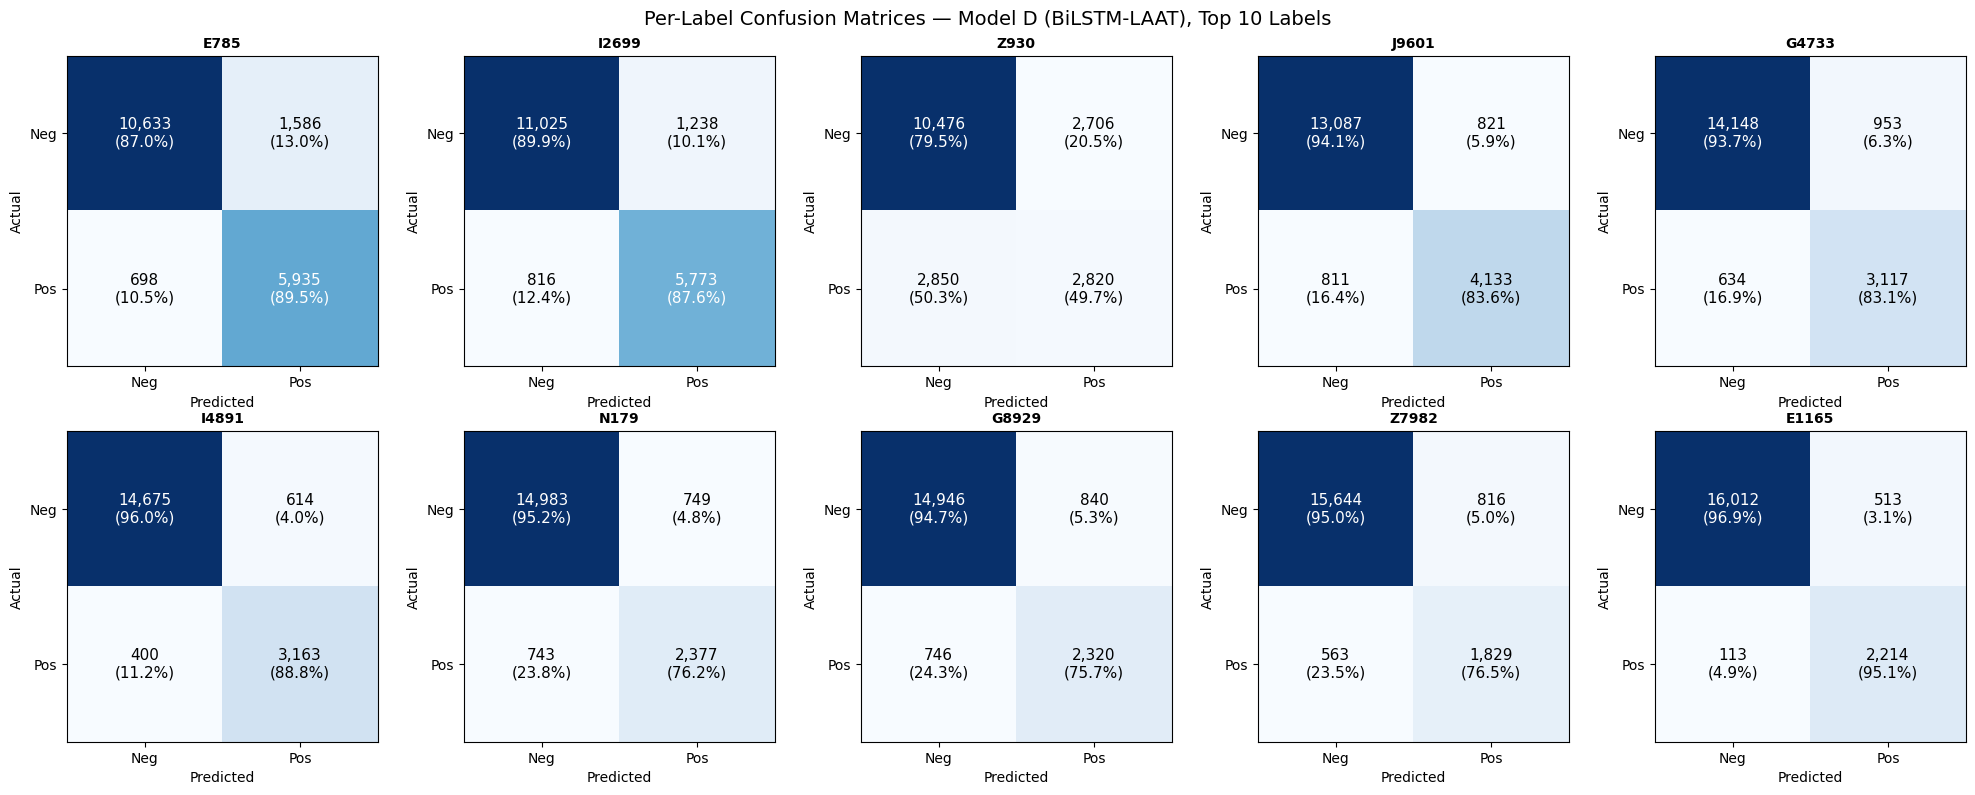


Aggregate Confusion Matrix (all 50 labels):
  TN =    817,990 (86.8%)   FP =     27,503 (2.9%)
  FN =     27,377 (2.9%)   TP =     69,730 (7.4%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from pathlib import Path
from sklearn.metrics import multilabel_confusion_matrix

DATA_DIR  = Path('../datasets/processed')
MODEL_DIR = Path('../data/models/model_d')
TOP_N = 10

with open(DATA_DIR / 'mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
vocab = list(mlb.classes_)

Y_test  = np.load(DATA_DIR / 'Y_test.npy')

P_test = np.load(MODEL_DIR / 'P_test_calibrated.npy')

with open(MODEL_DIR / 'test_results.json') as f:
    threshold = json.load(f)['Threshold']
preds_test = (P_test >= threshold).astype(int)

mcm = multilabel_confusion_matrix(Y_test, preds_test)

freq = Y_test.sum(0)
top_idx = np.argsort(freq)[::-1][:TOP_N]

nrows, ncols = 2, TOP_N // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for idx, ax in zip(top_idx, axes.flat):
    cm = mcm[idx]
    ax.imshow(cm, cmap='Blues')
    ax.set_title(vocab[idx], fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg', 'Pos']); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            color = 'white' if cm[r, c] > cm.max() / 2 else 'black'
            row_total = cm[r].sum()
            pct = cm[r, c] / row_total * 100 if row_total > 0 else 0
            ax.text(c, r, f'{cm[r, c]:,}\n({pct:.1f}%)', ha='center', va='center', color=color, fontsize=11)

plt.suptitle(f'Per-Label Confusion Matrices — Model D (BiLSTM-LAAT), Top {TOP_N} Labels', fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_DIR / f'confusion_matrix_top{TOP_N}.png', dpi=150)
plt.show()

agg = mcm.sum(axis=0)
print(f'\nAggregate Confusion Matrix (all {len(vocab)} labels):')
agg_total = agg.sum()
print(f'  TN = {agg[0,0]:>10,} ({agg[0,0]/agg_total*100:.1f}%)   FP = {agg[0,1]:>10,} ({agg[0,1]/agg_total*100:.1f}%)')
print(f'  FN = {agg[1,0]:>10,} ({agg[1,0]/agg_total*100:.1f}%)   TP = {agg[1,1]:>10,} ({agg[1,1]/agg_total*100:.1f}%)')

## 12. Full 50-Label Confusion Analysis
For each pair of labels (i, j): when label i is truly present in a sample, how often does the model **falsely** predict label j on that same sample? This reveals which ICD codes the model confuses with each other.

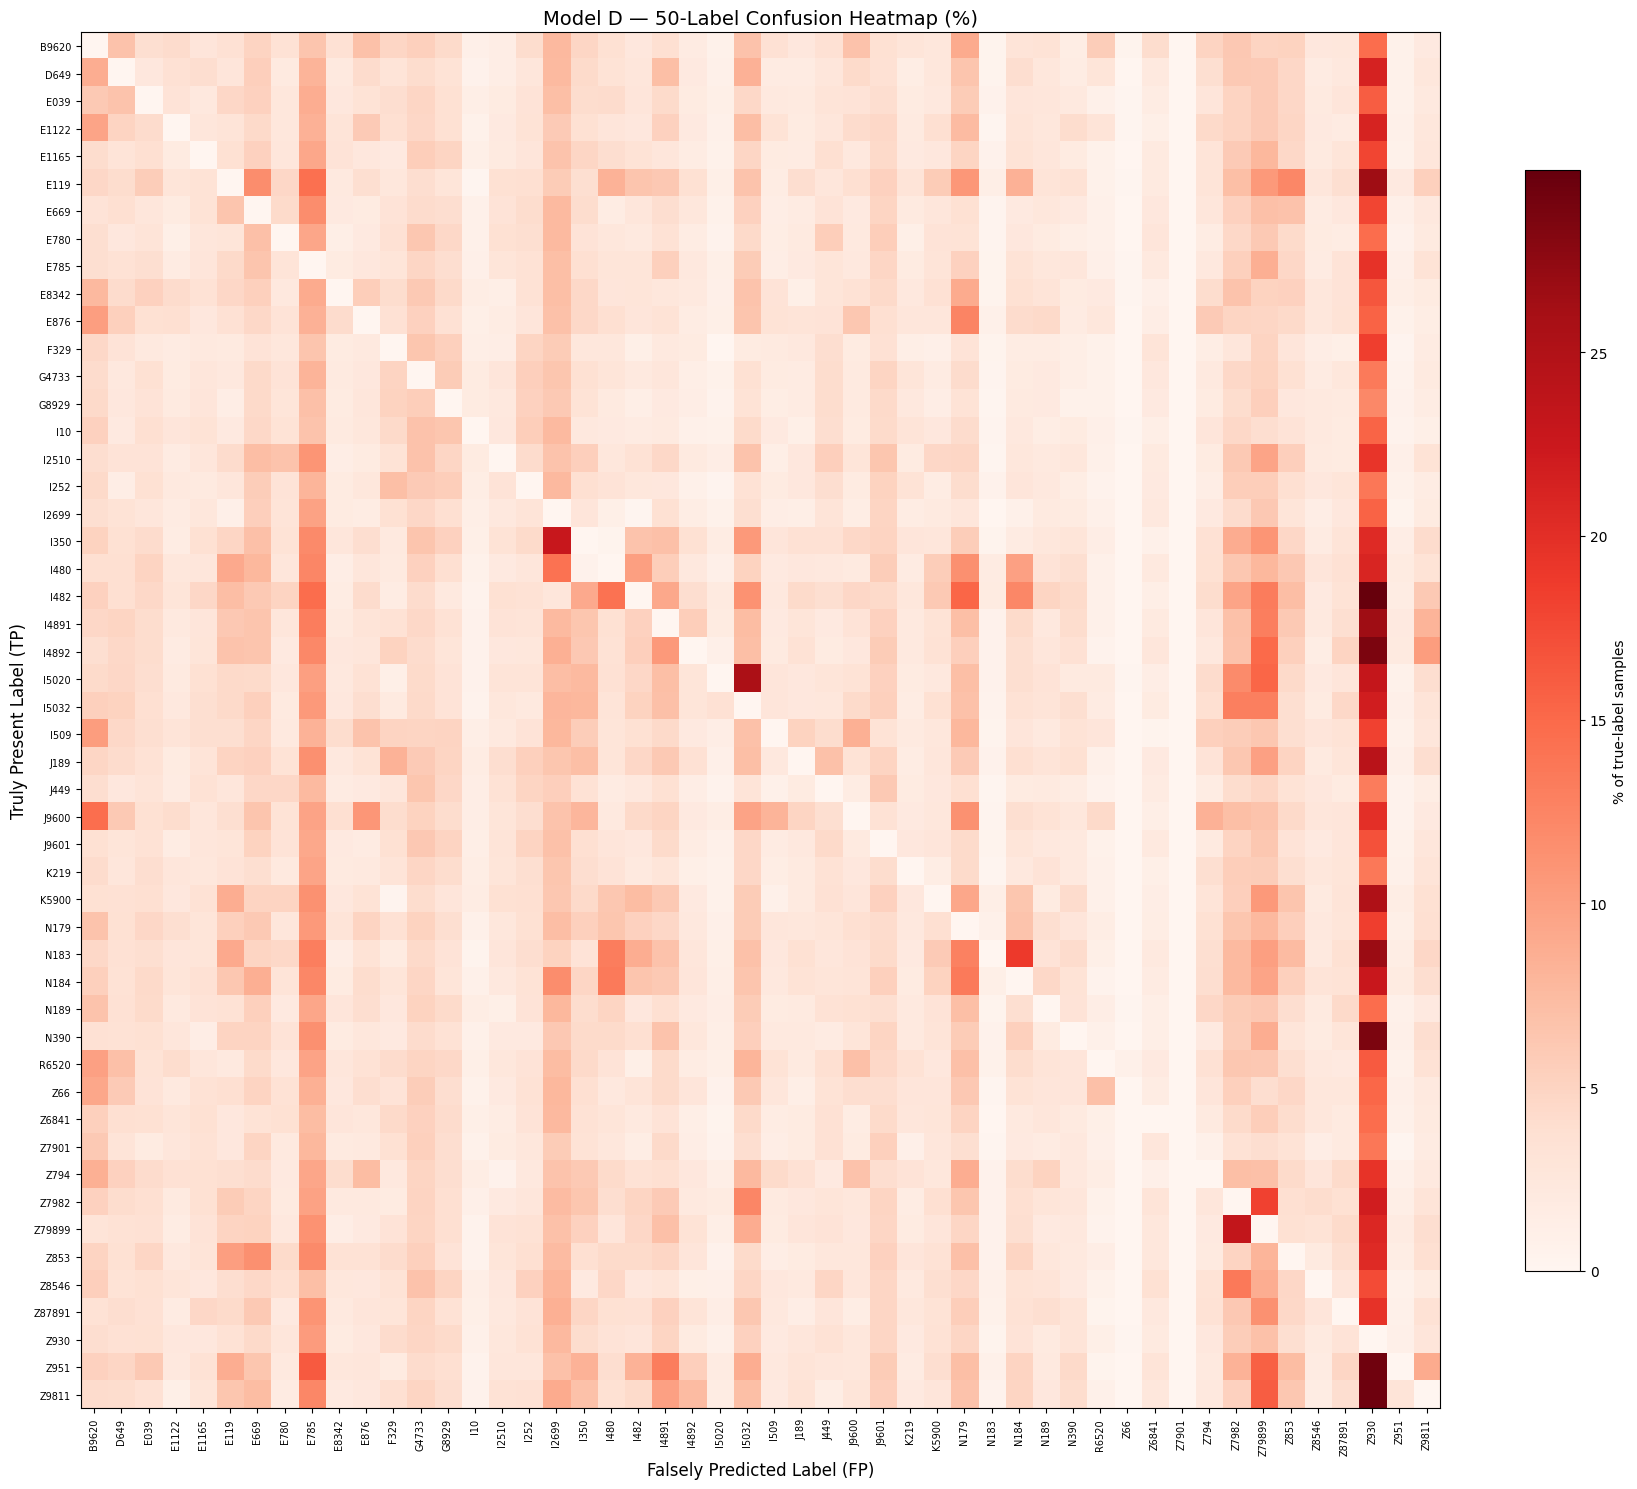


Top 20 most confused label pairs (Model D):
    True Label  →   Falsely Predicted    Count
  --------------------------------------------------
          E785  →                Z930    1,299  (19.6% of E785 samples)
         I2699  →                Z930    1,025  (15.6% of I2699 samples)
         I4891  →                Z930      943  (26.5% of I4891 samples)
         J9601  →                Z930      836  (16.9% of J9601 samples)
         I2699  →                E785      647  (9.8% of I2699 samples)
          Z930  →                E785      587  (10.4% of Z930 samples)
          N179  →                Z930      575  (18.4% of N179 samples)
          E785  →              Z79899      569  (8.6% of E785 samples)
         Z7982  →                Z930      521  (21.8% of Z7982 samples)
         G4733  →                Z930      502  (13.4% of G4733 samples)
          E785  →               I2699      473  (7.1% of E785 samples)
          Z853  →                Z930      472  (20.4% of Z8

In [2]:
TOP_PAIRS = 20
n_labels = len(vocab)

fp_mask = (preds_test == 1) & (Y_test == 0)
tp_mask = (Y_test == 1)

label_confusion = tp_mask.astype(int).T @ fp_mask.astype(int)

fig, ax = plt.subplots(figsize=(18, 15))
row_sums = tp_mask.sum(axis=0).reshape(-1, 1)
row_sums = np.where(row_sums == 0, 1, row_sums)
label_confusion_pct = label_confusion / row_sums * 100
im = ax.imshow(label_confusion_pct, cmap='Reds', aspect='auto', interpolation='nearest')
ax.set_xticks(range(n_labels)); ax.set_yticks(range(n_labels))
ax.set_xticklabels(vocab, rotation=90, fontsize=7)
ax.set_yticklabels(vocab, fontsize=7)
ax.set_xlabel('Falsely Predicted Label (FP)', fontsize=12)
ax.set_ylabel('Truly Present Label (TP)', fontsize=12)
ax.set_title(f'Model D — {n_labels}-Label Confusion Heatmap (%)', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8, label='% of true-label samples')
plt.tight_layout()
plt.savefig(MODEL_DIR / f'label_confusion_{n_labels}x{n_labels}.png', dpi=150)
plt.show()

np.fill_diagonal(label_confusion, 0)
flat_idx = np.argsort(label_confusion.ravel())[::-1]

print(f'\nTop {TOP_PAIRS} most confused label pairs (Model D):')
print(f'  {"True Label":>12s}  →  {"Falsely Predicted":>18s}  {"Count":>7s}')
print('  ' + '-' * 50)
shown = 0
for fi in flat_idx:
    if shown >= TOP_PAIRS:
        break
    i, j = divmod(fi, n_labels)
    count = label_confusion[i, j]
    if count == 0:
        break
    tp_total = tp_mask[:, i].sum()
    pct = count / tp_total * 100 if tp_total > 0 else 0
    print(f'  {vocab[i]:>12s}  →  {vocab[j]:>18s}  {count:>7,}  ({pct:.1f}% of {vocab[i]} samples)')
    shown += 1